In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from knapsack_solver import KnapsackSolver
import seaborn as sns
os.chdir(r"""C:\Users\thgla\Documents\GitHub\ADALaS""")


In [2]:
# FILENAMES = {
#     1: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_3.0x_rouge_scores_05-08_14-15-32.csv'),
#     #13: os.path.join('data','rouge_scores_ULS','ULS_1.85x_rouge_scores_29-07_17-48-23.csv'),
#     2: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_1.5x_rouge_scores_05-08_14-03-55.csv'),
#     3: os.path.join('data','rouge_scores_ULS','SAMSUM','ULS_1.0x_rouge_scores_05-08_13-58-14.csv')
#     }
FILENAMES = {
    1: os.path.join('data','prompt_classifier_dataset','ULS_3.0x_hT2_rouge_scores_11-08_13-50-04.csv'),
    #13: os.path.join('data','prompt_classifier_dataset','ULS_1.85x_train_rouge_scores_09-08_04-23-40.csv'),
    2: os.path.join('data','prompt_classifier_dataset','ULS_1.5x_hT2_rouge_scores_11-08_13-28-09.csv'),
    3: os.path.join('data','prompt_classifier_dataset','ULS_1.0x_hT2_rouge_scores_11-08_13-05-35.csv'),
    }


In [3]:
df_dict = {
    k: pd.read_csv(v) for k, v in FILENAMES.items()
}

In [4]:
print(df_dict[1].head())

         hash    rouge1    rouge2    rougeL  label_length  prediction_length  \
0  2744305639  0.235294  0.125000  0.176471            15                 28   
1  1732713607  0.444444  0.131148  0.285714            52                 29   
2  2542853174  0.387097  0.166667  0.290323            53                 21   
3  3225870289  0.210526  0.000000  0.157895            28                 18   
4  2961775682  0.500000  0.428571  0.500000            12                 12   

   prompt_length  
0            164  
1            195  
2            121  
3            164  
4            250  


In [5]:
print(df_dict[1]["rougeL"][:10]) 
print(df_dict[2]["rougeL"][0:10]) 
print(df_dict[3]["rougeL"][0:10]) 



0    0.176471
1    0.285714
2    0.290323
3    0.157895
4    0.500000
5    0.191781
6    0.333333
7    0.312500
8    0.436364
9    0.631579
Name: rougeL, dtype: float64
0    0.137931
1    0.285714
2    0.305556
3    0.177778
4    0.133333
5    0.395604
6    0.370370
7    0.307692
8    0.529412
9    0.631579
Name: rougeL, dtype: float64
0    0.146341
1    0.273973
2    0.246154
3    0.215385
4    0.285714
5    0.200000
6    0.560000
7    0.333333
8    0.611111
9    0.555556
Name: rougeL, dtype: float64


In [6]:
values = np.vstack([df['rougeL'].values for df in df_dict.values()]).T
weights = np.vstack([[k]*len(df) for k, df in df_dict.items()]).T

print(values[:5])
print(weights[:5])
print(values.shape)
print(weights.shape)


[[0.17647059 0.13793103 0.14634146]
 [0.28571429 0.28571429 0.2739726 ]
 [0.29032258 0.30555556 0.24615385]
 [0.15789474 0.17777778 0.21538462]
 [0.5        0.13333333 0.28571429]]
[[1 2 3]
 [1 2 3]
 [1 2 3]
 [1 2 3]
 [1 2 3]]
(7366, 3)
(7366, 3)


In [7]:
#take mean accross rows
means = np.mean(values, axis=0)
print(means)

#take max accross columns
maxes = np.max(values, axis=1)
max_mean = np.mean(maxes)
print(max_mean)


[0.37518891 0.38845761 0.39713354]
0.46292894161010795


In [8]:
#sort each row by value, and apply the same permutation to weights
sort_perm = np.argsort(-values, axis=1)
values_sorted = np.take_along_axis(values, sort_perm, axis=1)
weights_sorted = np.take_along_axis(weights, sort_perm, axis=1)





In [9]:
print(values_sorted[:5])
print(weights_sorted[:5])

[[0.17647059 0.14634146 0.13793103]
 [0.28571429 0.28571429 0.2739726 ]
 [0.30555556 0.29032258 0.24615385]
 [0.21538462 0.17777778 0.15789474]
 [0.5        0.28571429 0.13333333]]
[[1 3 2]
 [1 2 3]
 [2 1 3]
 [3 2 1]
 [1 3 2]]


In [10]:
#truncate dataset to 1000
# values_sorted = values_sorted[:1000]
# weights_sorted = weights_sorted[:1000]

In [11]:
#KNAPSACK!
max_capacity = values_sorted.shape[0] * 3
print(f'matrix shape: {values_sorted.shape[0]}, {max_capacity}')


matrix shape: 7366, 22098


In [12]:
#KNAPSACK!

kp_solver = KnapsackSolver(max_capacity, values_sorted, weights_sorted)

optimal_rouges = kp_solver.solve()

100%|██████████| 7365/7365 [03:34<00:00, 34.35it/s]


In [13]:
#find last occurence of -np.inf
last_inf = np.where(optimal_rouges == -np.inf)[0][-1] 

In [14]:
optimal_rouges_clean = optimal_rouges[last_inf+1:]

In [15]:
#divide by number of rows
optimal_rouges_final = optimal_rouges_clean / values_sorted.shape[0]
print(optimal_rouges_final)

[0.37518793 0.37528747 0.37538445 ... 0.46292692 0.46292692 0.46292692]


In [16]:
#average rouge scores for each df in df_dict
ULS_constant_rouges = [df['rougeL'].mean() for df in df_dict.values()]
ULS_layer_use = [k*8 for k in df_dict.keys()]

optimal_rouge_layer_use = np.arange(last_inf+1, last_inf+1+len(optimal_rouges_final))* 8 / values_sorted.shape[0]

In [17]:
print(optimal_rouge_layer_use  )

[ 8.          8.00108607  8.00217214 ... 23.99782786 23.99891393
 24.        ]


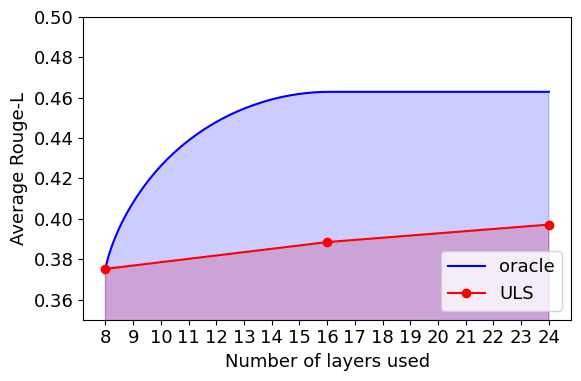

In [18]:
plt.figure(figsize=(6,4))
#font size
plt.rc('font', size=13)
plt.plot(optimal_rouge_layer_use, optimal_rouges_final, label='oracle', color='blue')
#scatter with line connecting points
plt.plot(ULS_layer_use, ULS_constant_rouges, label='ULS', color='red', marker='o')
#compare AUC
plt.fill_between(ULS_layer_use, ULS_constant_rouges, alpha=0.2, color='red')
plt.fill_between(optimal_rouge_layer_use, optimal_rouges_final, alpha=0.2, color='blue')
plt.xlabel('Number of layers used')
plt.ylabel('Average Rouge-L')
#change y range
plt.ylim(0.35, 0.50)
plt.legend(loc='lower right', fontsize=13)
plt.xticks(np.arange(8, 25, 1))
plt.tight_layout()

plt.show()
#why is savefig showing a blank image?
#A: 





In [19]:
#save optimal_rouges
#np.save(r'data\rouge_scores_ULS\oracle_rouges.npy', optimal_rouges)

In [20]:
average_layers = [1,2,3]
average_layers_2 = [8, 16, 24]
choices_for_layer = [kp_solver.reconstruct_chosen_items(layer*values_sorted.shape[0]) for layer in average_layers]
occurences_model = [[0,0,0] for _ in range(len(choices_for_layer))]
for i in range(len(choices_for_layer)):
    occurences_model[i][0] += choices_for_layer[i].count(1) / float(values_sorted.shape[0])
    occurences_model[i][1] += choices_for_layer[i].count(2) / float(values_sorted.shape[0])
    occurences_model[i][2] += choices_for_layer[i].count(3) / float(values_sorted.shape[0])



In [21]:
print(choices_for_layer[1])
#convert choices for layer to classes 0-3
occurences_model_array = np.array(occurences_model)
class_dict = {1: 0, 2: 1, 3: 2}
class_labels = np.array([class_dict[c] for c in choices_for_layer[1]])



#create new pd df with hash and class
hashes = df_dict[1]['hash']
df_class = pd.DataFrame({'hash': hashes, 'class': class_labels})
#append all rouge scores
for i, df in df_dict.items():
    df_class[f'rouge_{i}'] = df['rougeL']

#save to csv
df_class.to_csv(r'data\prompt_classifier_dataset\layer_15_classes_3C.csv', index=True)



[1, 1, 2, 3, 1, 2, 3, 3, 3, 1, 1, 1, 1, 2, 1, 1, 3, 1, 2, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 1, 3, 2, 1, 3, 3, 3, 2, 2, 3, 1, 1, 3, 3, 1, 3, 2, 2, 3, 2, 1, 1, 3, 2, 2, 2, 3, 3, 1, 3, 1, 2, 3, 3, 2, 2, 3, 3, 2, 2, 3, 3, 3, 1, 1, 1, 2, 3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 3, 1, 1, 3, 1, 2, 3, 2, 2, 2, 2, 1, 1, 3, 2, 2, 3, 1, 1, 3, 1, 2, 1, 2, 1, 2, 2, 3, 3, 2, 3, 3, 2, 2, 1, 2, 3, 3, 1, 1, 1, 2, 2, 3, 2, 2, 3, 3, 3, 3, 3, 3, 1, 2, 2, 1, 3, 3, 2, 2, 3, 3, 1, 1, 2, 1, 2, 2, 1, 2, 3, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 1, 2, 2, 3, 3, 3, 2, 3, 3, 1, 1, 3, 3, 3, 2, 2, 2, 1, 3, 3, 1, 3, 2, 2, 3, 3, 1, 1, 1, 1, 1, 2, 1, 3, 1, 1, 2, 2, 1, 2, 1, 1, 1, 1, 3, 2, 2, 2, 2, 2, 2, 1, 3, 3, 2, 3, 3, 3, 3, 2, 1, 3, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 2, 1, 1, 1, 2, 2, 3, 3, 3, 1, 3, 3, 1, 1, 1, 1, 2, 1, 1, 1, 3, 2, 2, 2, 1, 2, 3, 3, 3, 3, 2, 1, 2, 1, 3, 3, 3, 2, 1, 3, 2, 3, 3, 3, 2, 1, 1, 3, 3, 3, 2, 2, 1, 3, 1, 3, 1, 1, 1, 2, 1, 1, 2, 2, 1, 3, 1, 3, 1, 2, 2, 1, 3, 2, 3, 3, 3, 1, 2, 1, 1, 3, 3, 3, 2, 2, 2, 3, 3, 1, 2, 

In [22]:
#test that we can reconstruct the optimal solution
rouges = []
for i in range(len(df_class['hash'])):
    row = df_class.iloc[i]
    rouge = row[f'rouge_{int(row["class"])+1}']
    rouges.append(rouge)

print(np.mean(rouges))

0.4629268314461499


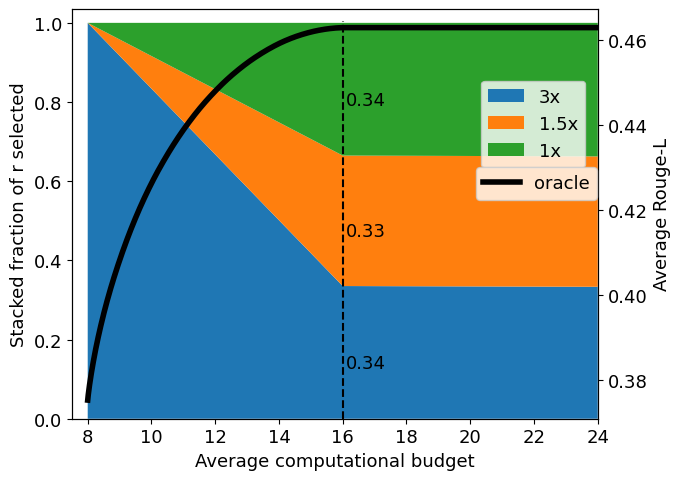

In [23]:
#defuat style
plt.style.use('default')
plt.rc('font', size=13)
plt.figure(figsize=(7,5))
# plot as stacked line chart,
occurences_model = np.array(occurences_model)
plt.stackplot(average_layers_2, occurences_model.T, labels=['3x', '1.5x', '1x'])
plt.legend(loc=(0.778,0.614))
plt.xlabel('Average computational budget')
plt.ylabel('Stacked fraction of r selected')

#add vertical dashed line at 15
plt.axvline(x=16, color='black', linestyle='--',ymax=0.97)
#add text of values of occurences_model at 12
for i, txt in enumerate(occurences_model[1]):
    plt.text(16.1, sum(occurences_model[1,:i]) + 0.38*occurences_model[1,i], str(round(txt,2)), color='black')
# for i, txt in enumerate(occurences_model[4]):
#     plt.text(11.1, sum(occurences_model[4,:i]) + 0.38*occurences_model[4,i], str(round(txt,2)), color='black')
plt.grid(False)
plt.ylim(0,1.035)
#add rouge socre on secondary y axis
plt.twinx()
plt.ylabel('Average Rouge-L')
#plt.ylim(0.277, 0.360)
#plt.ylim(0.37, 0.447)
plt.plot(optimal_rouge_layer_use, optimal_rouges_final, label='oracle', color='black',linewidth=4)
plt.legend(loc=(0.769,0.535))
#hide grid 
plt.grid(False)
plt.xlim(7.5,24)
plt.tight_layout()

plt.show()

In [16]:
from src.models.adalas_opt.modeling_adalas_opt import AdalasOPTForCausalLM
from src.models.adalas_opt.config_adalas_opt import AdalasOPTConfig
#auto tokenization
from src.utils.utils import fix_the_seed
from transformers import AutoTokenizer

In [17]:

config = AdalasOPTConfig.from_pretrained('facebook/opt-125M')
model = AdalasOPTForCausalLM.from_pretrained('facebook/opt-125M', config=config)
tokenizer = AutoTokenizer.from_pretrained('facebook/opt-125M')

You are using a model of type opt to instantiate a model of type adalas_opt. This is not supported for all configurations of models and can yield errors.


In [29]:
fix_the_seed(123)
input_ids = tokenizer.encode("Today is a good day to", return_tensors='pt')
output = model.generate(input_ids, max_length=50,do_sample=True,temperature=0.9)
print(tokenizer.decode(output[0], skip_special_tokens=True))

Today is a good day to get some new shirts. The other day I had my shirt made for an art class and the girls tried to put it in a different piece of fabric (which was a bit messy but I like it) but it


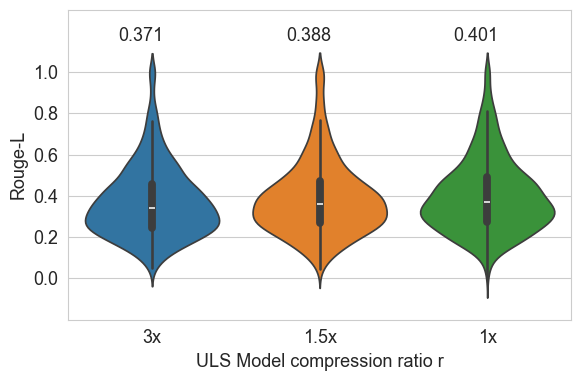

In [27]:
#set style seaborn
sns.set_style('whitegrid')
#violin plots of rouge scores, colorful
plt.figure(figsize=(6,4))
violin_data = {
    '3x': df_dict[1]['rougeL'],
    '1.5x': df_dict[2]['rougeL'],
    '1x': df_dict[3]['rougeL']
}
sns.violinplot(data=violin_data)
#show average rouge scores
for i, (k, v) in enumerate(violin_data.items()):
    plt.text(i, v.mean(), f'{v.mean():.3f}', position=(i-0.2,1.15))
plt.xticks(np.arange(3), ['3x', '1.5x', '1x'])
plt.ylim(-0.2, 1.3)
plt.yticks(np.arange(0, 1.1, 0.2))
plt.ylabel('Rouge-L')
plt.xlabel('ULS Model compression ratio r')
plt.tight_layout()

plt.show()